In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 350
sigma = 0.25                                 # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, 400)


# Sentrering av y:
Bør gi samme type data, noe den gjør.

In [22]:
#lambdas = [1e-2, 1e-1, 0.5, 1.0, 1e1]
maxdeg = 15
deg_V = np.arange(maxdeg + 1)
lambdas = np.logspace(-3, 2, 5)
MSE_grid = np.zeros((maxdeg + 1, len(lambdas)))
R2_grid = np.zeros((maxdeg + 1, len(lambdas)))

for degree in range(maxdeg + 1):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.3, random_state=2026)

    # Beregn gjennomsnitt og standardavvik fra treningsdata
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Behold konstantkolonnen: (1 - 0) / 1 = 1
    mean[0] = 0
    std[0] = 1

    X_train_norm = (X_train - mean) / std
    X_test_norm = (X_test - mean) / std
    # Trenger ikke sentrere y da design matrisen inneholder intercept
    y_train_mean = y_train.mean(axis=0)
    y_train_c = y_train - y_train_mean
    #X_train_norm = X_train 
    #X_test_norm = X_test


    for i, lmb in enumerate(lambdas):
        I = np.eye(X_train_norm.shape[1])
        I[0,0] = 0.0 # Vil ikke at intercept skal bli straffet av Ridge
        
        theta = np.linalg.pinv((X_train_norm).T @ (X_train_norm) + lmb*I) @ (X_train_norm).T @ y_train_c
        y_predict = X_test_norm @ theta + y_train_mean

        MSE_grid[degree, i] = np.mean((y_test - y_predict)**2)
        y_test_mean = np.mean(y_test)
        R2_grid[degree, i] = (
            1 - np.sum((y_test - y_predict)**2) 
            / np.sum((y_test - y_test_mean)**2))

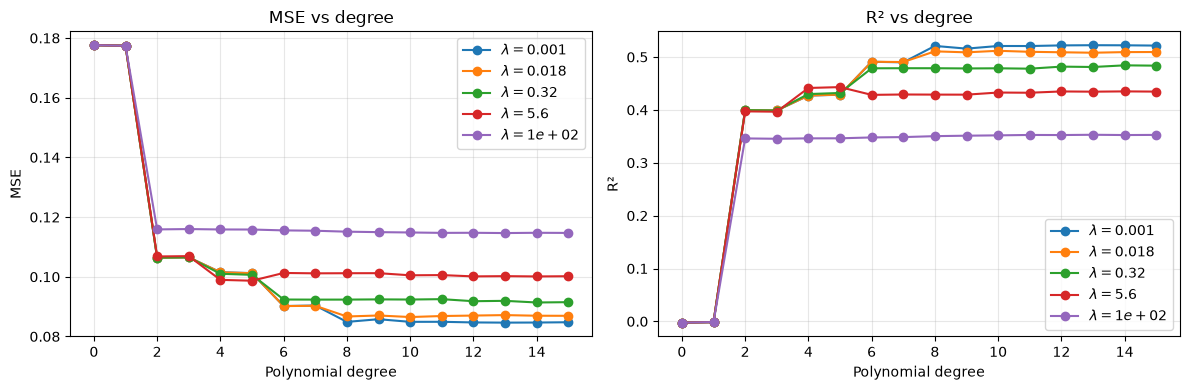

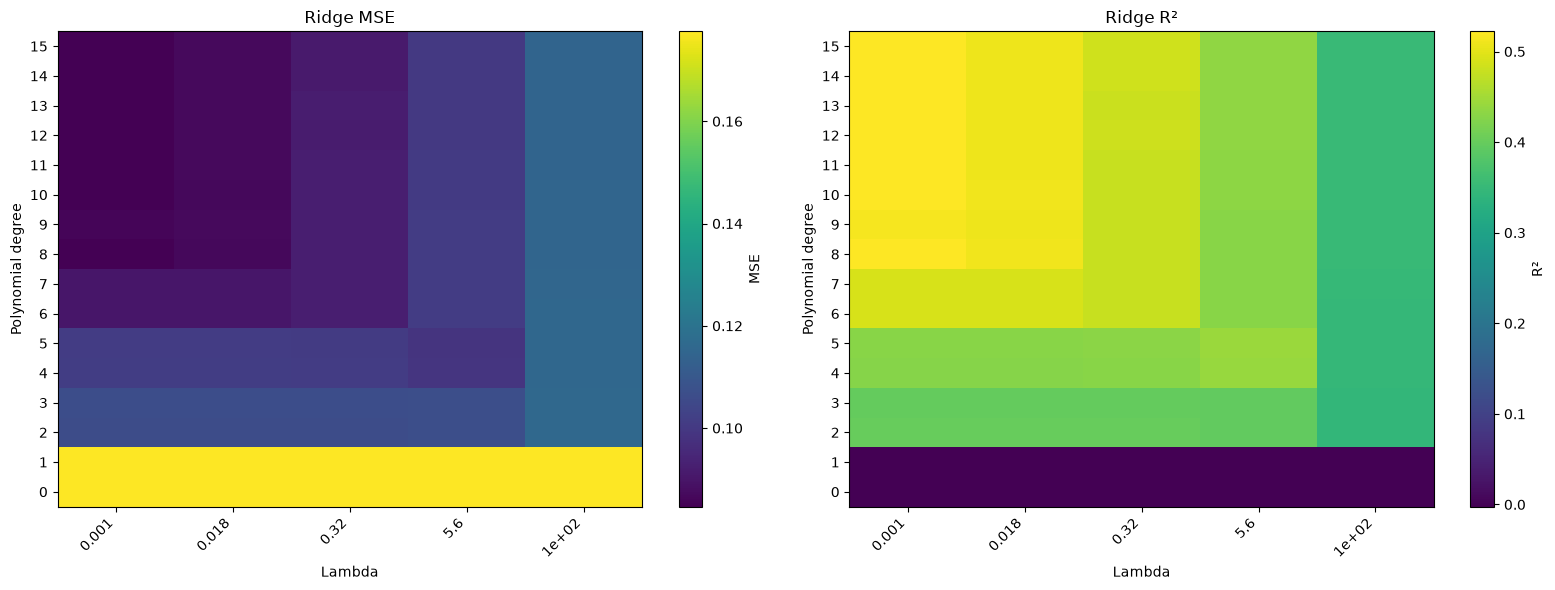

In [23]:
# b) plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, lam in enumerate(lambdas):
    axes[0].plot(deg_V, MSE_grid[:, i], marker="o", label=rf"$\lambda={lam:.2g}$")
    axes[1].plot(deg_V, R2_grid[:, i], marker="o", label=rf"$\lambda={lam:.2g}$")

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE vs degree")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("R²")
axes[1].set_title("R² vs degree")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MSE heatmap
im1 = axes[0].imshow(MSE_grid, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Ridge MSE")
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Polynomial degree")
axes[0].set_xticks(np.arange(len(lambdas)))
axes[0].set_xticklabels([f"{lam:.2g}" for lam in lambdas], rotation=45, ha="right")
axes[0].set_yticks(np.arange(maxdeg + 1))
axes[0].set_yticklabels(deg_V)
fig.colorbar(im1, ax=axes[0], label="MSE")

# R² heatmap
im2 = axes[1].imshow(R2_grid, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("Ridge R²")
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Polynomial degree")
axes[1].set_xticks(np.arange(len(lambdas)))
axes[1].set_xticklabels([f"{lam:.2g}" for lam in lambdas], rotation=45, ha="right")
axes[1].set_yticks(np.arange(maxdeg + 1))
axes[1].set_yticklabels(deg_V)
fig.colorbar(im2, ax=axes[1], label="R²")

plt.tight_layout()
plt.show()